# Benchmark of Transformer Performance on Probability Distribution Inference

Welcome to this comprehensive benchmark tutorial! In this study, we evaluate the performance of a **Permutation-Invariant Transformer** and a **Baseline Multi-Layer Perceptron (MLP)** of roughly the same size (~75k parameters) at predicting the defining latent parameters of four probability distributions: **Exponential**, **Gamma**, **Beta**, and **Log-Normal**.

We evaluate both neural network models against **classical sample statistics baselines** (such as Maximum Likelihood Estimation and the Method of Moments) computed from a 12-dimensional sequence of independent and identically distributed (i.i.d.) samples.

---

## 1. Educational Objectives & Theory

By the end of this tutorial, you will understand:
1. **The mathematical structure and parameters** of four fundamental probability distributions (Exponential, Gamma, Beta, and Log-Normal).
2. **Classical estimators** (Maximum Likelihood and Method of Moments) and their theoretical behavior for small sample sizes ($D=12$).
3. **Permutation Invariance as an inductive bias**: why standard MLPs must laboriously learn to treat i.i.d. samples symmetrically, whereas Transformers with no positional encodings and symmetric pooling are strictly permutation-invariant by design.
4. **How Self-Attention Models Variance**: how the dot-product attention matrix $Q K^T$ natively computes pairwise multiplicative terms ($x_i x_j$), corresponding directly to the algebraic definition of sample variance.
5. **Quantitative benchmarks** proving how deep neural networks, and particularly Transformers, perform compared to classical formulas and standard dense architectures.


## 2. Probability Distributions & Classical Estimators

We draw a sequence of $D = 12$ i.i.d. samples $x_1, x_2, \dots, x_D$ from a target distribution. Let's look at the mathematical formulations and estimators for each of the four distributions:

### A. Exponential Distribution
- **Probability Density Function (PDF)**: $f(x) = \lambda e^{-\lambda x}$ for $x \ge 0$, where $\lambda > 0$ is the rate parameter.
- **Defining Parameter**: Rate $\lambda$.
- **Classical Estimator (MLE)**: The maximum likelihood estimator of $\lambda$ is the reciprocal of the sample mean:
  $$\hat{\lambda}_{MLE} = \frac{1}{\bar{x}} = \frac{D}{\sum_{i=1}^D x_i}$$

### B. Gamma Distribution
- **Probability Density Function (PDF)**: $f(x) = \frac{1}{\Gamma(k)\theta^k} x^{k-1} e^{-\frac{x}{\theta}}$ for $x > 0$, where $k > 0$ is the shape parameter and $\theta > 0$ is the scale parameter.
- **Defining Parameters**: Shape $k$ and Scale $\theta$.
- **Classical Estimators (Method of Moments)**:
  Let the sample mean be $\bar{x}$ and sample variance be $s^2 = \frac{1}{D-1}\sum (x_i - \bar{x})^2$. Since $E[X] = k\theta$ and $\text{Var}(X) = k\theta^2$, we solve:
  $$\hat{\theta}_{MoM} = \frac{s^2}{\bar{x}}, \quad \hat{k}_{MoM} = \frac{\bar{x}^2}{s^2}$$

### C. Beta Distribution
- **Probability Density Function (PDF)**: $f(x) = \frac{1}{\text{B}(\alpha, \beta)} x^{\alpha-1} (1-x)^{\beta-1}$ for $x \in [0, 1]$, where $\alpha > 0$ and $\beta > 0$ are the shape parameters.
- **Defining Parameters**: Shape parameters $\alpha$ and $\beta$.
- **Classical Estimators (Method of Moments)**:
  Using sample mean $\bar{x}$ and sample variance $s^2$, let $V = \frac{\bar{x}(1-\bar{x})}{s^2} - 1$. The estimators are:
  $$\hat{\alpha}_{MoM} = \bar{x} V, \quad \hat{\beta}_{MoM} = (1 - \bar{x}) V$$

### D. Log-Normal Distribution
- **Probability Density Function (PDF)**: $f(x) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\left( -\frac{(\ln x - \mu)^2}{2\sigma^2} \right)$ for $x > 0$, where $\mu$ is the mean and $\sigma > 0$ is the standard deviation of the variable's natural logarithm.
- **Defining Parameters**: Log-mean $\mu$ and Log-std $\sigma$.
- **Classical Estimators (MLE)**:
  Let $y_i = \ln(x_i)$. The estimators are the sample mean and sample standard deviation of the log-transformed values:
  $$\hat{\mu}_{MLE} = \bar{y} = \frac{1}{D} \sum_{i=1}^D y_i, \quad \hat{\sigma}_{MLE} = s_y = \sqrt{\frac{1}{D-1} \sum_{i=1}^D (y_i - \bar{y})^2}$$


## 3. Neural Network Architectures & Parameter Matching

To ensure a fair and rigorous comparison, we parameter-match both networks to be approximately **71k - 75k parameters**:

### 1. Baseline MLP (~75k parameters)
- Hidden dimensions: `[256, 200, 100]` with ReLU activations.
- Input size is 12 (the flat sample vector).
- Total parameters calculation:
  - Layer 1: $12 \times 256 + 256 = 3,328$
  - Layer 2: $256 \times 200 + 200 = 51,400$
  - Layer 3: $200 \times 100 + 100 = 20,100$
  - Head: $100 \times N_{\text{out}} + N_{\text{out}} \approx 200$
  - **Total**: $\approx 75,030$ parameters.

### 2. Permutation-Invariant Transformer (~71.5k parameters)
- Treating input as 12 individual 1D tokens.
- Input projection: from 1 to `d_model = 64` ($128$ parameters).
- Two custom transformer encoder layers (`num_layers=2`) with `d_model = 64`, `nhead = 4`, and `dim_feedforward = 128`.
- Each encoder layer contains scratch Multi-Head Attention and a Feedforward Network, consuming $\approx 33,472$ parameters per layer.
- Output projection head: from 64 to 64 to outputs ($\approx 4,300$ parameters).
- **Total**: $\approx 71,372$ parameters.
- **Permutation Invariance**: Strictly guaranteed by omitting positional encodings and using global average pooling across the sequence dimension before feeding features to the regression head.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Environment setup complete. Device:", device, "PyTorch Version:", torch.__version__)


Environment setup complete. Device: cpu PyTorch Version: 2.13.0+cu130


## 4. Standardizer and Data Generators

We create a robust `Standardizer` class to scale our model inputs and targets, keeping the training dynamics stable and preventing data leakage by fitting exclusively on the training split.

In [2]:
class Standardizer:
    """Utility class to scale inputs and targets to zero mean and unit variance."""
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, data):
        self.mean = np.mean(data, axis=0, keepdims=True)
        self.std = np.std(data, axis=0, keepdims=True)
        self.std[self.std == 0.0] = 1.0

    def transform(self, data):
        return (data - self.mean) / self.std

    def fit_transform(self, data):
        self.fit(data)
        return self.transform(data)

    def inverse_transform(self, data):
        return data * self.std + self.mean

def generate_exponential_dataset(num_samples=12000, sequence_length=12):
    """Exp(lambda) distribution, lambda uniformly varying in range [0.5, 5.0]."""
    lambdas = np.random.uniform(0.5, 5.0, size=(num_samples, 1))
    X = np.random.exponential(scale=1.0 / lambdas, size=(num_samples, sequence_length))
    Y = lambdas
    return X, Y

def generate_gamma_dataset(num_samples=12000, sequence_length=12):
    """Gamma(shape k, scale theta) distribution, with parameters varying uniformly."""
    k = np.random.uniform(1.0, 5.0, size=(num_samples, 1))
    theta = np.random.uniform(0.5, 3.0, size=(num_samples, 1))
    X = np.random.gamma(shape=k, scale=theta, size=(num_samples, sequence_length))
    Y = np.hstack([k, theta])
    return X, Y

def generate_beta_dataset(num_samples=12000, sequence_length=12):
    """Beta(alpha, beta) distribution with shape parameters varying uniformly."""
    alpha = np.random.uniform(1.0, 5.0, size=(num_samples, 1))
    beta = np.random.uniform(1.0, 5.0, size=(num_samples, 1))
    X = np.random.beta(a=alpha, b=beta, size=(num_samples, sequence_length))
    Y = np.hstack([alpha, beta])
    return X, Y

def generate_lognormal_dataset(num_samples=12000, sequence_length=12):
    """Lognormal(mu, sigma) distribution with log-mean and log-std varying uniformly."""
    mu = np.random.uniform(-1.0, 1.0, size=(num_samples, 1))
    sigma = np.random.uniform(0.2, 1.5, size=(num_samples, 1))
    X = np.random.lognormal(mean=mu, sigma=sigma, size=(num_samples, sequence_length))
    Y = np.hstack([mu, sigma])
    return X, Y


## 5. Model Implementations from Scratch

We implement a custom multi-head self-attention module, a single transformer encoder layer, and the complete `PermutationInvariantTransformer`. We also define our `BaselineMLP` of matched parameter size.

In [3]:
class CustomMultiHeadAttention(nn.Module):
    """Scratch implementation of Multi-Head Self-Attention."""
    def __init__(self, d_model=64, nhead=4):
        super().__init__()
        assert d_model % nhead == 0, "d_model must be divisible by nhead"
        self.d_model = d_model
        self.nhead = nhead
        self.d_k = d_model // nhead
        
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
    def forward(self, x, return_attention=False):
        batch_size, seq_len, _ = x.size()
        
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        
        # Reshape: (batch, nhead, seq_len, d_k)
        q = q.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.nhead, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn_probs = torch.softmax(scores, dim=-1)
        
        context = torch.matmul(attn_probs, v)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.out_proj(context)
        
        if return_attention:
            return output, attn_probs
        return output

class CustomTransformerEncoderLayer(nn.Module):
    """Scratch implementation of a Transformer Encoder Layer."""
    def __init__(self, d_model=64, nhead=4, dim_feedforward=128, dropout=0.0):
        super().__init__()
        self.mha = CustomMultiHeadAttention(d_model, nhead)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout)
        )
        
    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_probs = self.mha(x, return_attention=True)
        else:
            attn_out = self.mha(x, return_attention=False)
            
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        
        if return_attention:
            return x, attn_probs
        return x

class PermutationInvariantTransformer(nn.Module):
    """Symmetric, Position-Free Self-Attention Network."""
    def __init__(self, seq_len=12, d_model=64, nhead=4, dim_feedforward=128, num_layers=2, output_dim=2):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        
        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(d_model, nhead, dim_feedforward)
            for _ in range(num_layers)
        ])
        
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, output_dim)
        )

    def forward(self, x, return_attention=False):
        tokens = x.unsqueeze(-1)
        emb = self.input_projection(tokens)
        
        attn_maps = []
        h = emb
        for layer in self.layers:
            if return_attention:
                h, attn = layer(h, return_attention=True)
                attn_maps.append(attn)
            else:
                h = layer(h)
                
        # Global average pool across sequence elements for strict permutation invariance
        pooled = h.mean(dim=1)
        out = self.head(pooled)
        
        if return_attention:
            return out, attn_maps
        return out

class BaselineMLP(nn.Module):
    """Standard Feedforward MLP with roughly matched parameter capacity."""
    def __init__(self, input_dim=12, hidden_dims=[256, 200, 100], output_dim=2):
        super().__init__()
        layers = []
        curr_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(curr_dim, h))
            layers.append(nn.ReLU())
            curr_dim = h
        layers.append(nn.Linear(curr_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


## 6. Classical Estimator Formulas

We implement the numerical and statistical estimators (MLE / Method of Moments) for all distributions to serve as classical baselines.

In [4]:
def estimate_exponential_classical(X):
    mean = np.mean(X, axis=1, keepdims=True)
    mean = np.clip(mean, 1e-6, None)
    return 1.0 / mean

def estimate_gamma_classical(X):
    mean = np.mean(X, axis=1, keepdims=True)
    var = np.var(X, axis=1, ddof=1, keepdims=True)
    mean = np.clip(mean, 1e-6, None)
    var = np.clip(var, 1e-6, None)
    theta_est = var / mean
    k_est = (mean ** 2) / var
    return np.hstack([k_est, theta_est])

def estimate_beta_classical(X):
    mean = np.mean(X, axis=1, keepdims=True)
    var = np.var(X, axis=1, ddof=1, keepdims=True)
    mean = np.clip(mean, 1e-6, 1.0 - 1e-6)
    var = np.clip(var, 1e-6, None)
    term = (mean * (1.0 - mean) / var) - 1.0
    term = np.clip(term, 1e-6, None)
    alpha_est = mean * term
    beta_est = (1.0 - mean) * term
    return np.hstack([alpha_est, beta_est])

def estimate_lognormal_classical(X):
    X_clipped = np.clip(X, 1e-6, None)
    log_X = np.log(X_clipped)
    mu_est = np.mean(log_X, axis=1, keepdims=True)
    sigma_est = np.std(log_X, axis=1, ddof=1, keepdims=True)
    return np.hstack([mu_est, sigma_est])


## 7. Unified Dataset Wrapper & Training Framework

We write a unified, robust training script that will accept a dataset, standardise it, construct the two models, run optimization for 50 epochs, evaluate the models and classical estimators, and return all training logs and test results.

In [5]:
class GaussianDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

def benchmark_distribution(dist_name, gen_func, est_func, output_dim=2, epochs=50):
    print(f"\n{'='*40}\nStarting Benchmark for: {dist_name}\n{'='*40}")
    
    # 1. Generate Dataset
    X_raw, Y_raw = gen_func()
    
    # Split: 70% Train, 15% Val, 15% Test
    n_total = len(X_raw)
    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)
    
    X_train_raw, Y_train_raw = X_raw[:n_train], Y_raw[:n_train]
    X_val_raw, Y_val_raw = X_raw[n_train:n_train+n_val], Y_raw[n_train:n_train+n_val]
    X_test_raw, Y_test_raw = X_raw[n_train+n_val:], Y_raw[n_train+n_val:]
    
    # Standardize data to stabilize networks
    input_scaler = Standardizer()
    target_scaler = Standardizer()
    
    X_train = input_scaler.fit_transform(X_train_raw)
    Y_train = target_scaler.fit_transform(Y_train_raw)
    
    X_val = input_scaler.transform(X_val_raw)
    Y_val = target_scaler.transform(Y_val_raw)
    
    X_test = input_scaler.transform(X_test_raw)
    Y_test = target_scaler.transform(Y_test_raw)
    
    train_loader = DataLoader(GaussianDataset(X_train, Y_train), batch_size=128, shuffle=True)
    val_loader = DataLoader(GaussianDataset(X_val, Y_val), batch_size=128, shuffle=False)
    
    # Define Models
    mlp = BaselineMLP(input_dim=12, output_dim=output_dim).to(device)
    transformer = PermutationInvariantTransformer(seq_len=12, output_dim=output_dim).to(device)
    
    # Train models
    histories = {}
    for model, name in [(mlp, "MLP"), (transformer, "Transformer")]:
        optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
        criterion = nn.MSELoss()
        
        train_losses = []
        val_losses = []
        
        t0 = time.time()
        for epoch in range(epochs):
            model.train()
            epoch_train = []
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                
                epoch_train.append(loss.item())
                
            # Validation
            model.eval()
            epoch_val = []
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_preds = model(xb)
                    val_loss = criterion(val_preds, yb)
                    epoch_val.append(val_loss.item())
                    
            train_losses.append(np.mean(epoch_train))
            val_losses.append(np.mean(epoch_val))
            
        elapsed = time.time() - t0
        histories[name] = {"train": train_losses, "val": val_losses, "time": elapsed}
        print(f"{name} completed 50 epochs in {elapsed:.2f} seconds. Final Val Loss: {val_losses[-1]:.5f}")
        
    # Evaluate on Test Set
    mlp.eval()
    transformer.eval()
    test_x_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        mlp_preds_scaled = mlp(test_x_tensor).cpu().numpy()
        trans_preds_scaled = transformer(test_x_tensor).cpu().numpy()
        
    mlp_preds = target_scaler.inverse_transform(mlp_preds_scaled)
    trans_preds = target_scaler.inverse_transform(trans_preds_scaled)
    
    # Classical Estimation on raw test inputs
    classical_preds = est_func(X_test_raw)
    
    # Compute metrics for each target variable
    metrics = {}
    targets_names = ["Param_1", "Param_2"] if output_dim == 2 else ["Param_1"]
    
    for i, p_name in enumerate(targets_names):
        y_true_col = Y_test_raw[:, i]
        
        # MLP
        y_mlp = mlp_preds[:, i]
        # Trans
        y_trans = trans_preds[:, i]
        # Classical
        y_class = classical_preds[:, i]
        
        metrics[p_name] = {
            "MLP": {
                "MAE": mean_absolute_error(y_true_col, y_mlp),
                "MSE": mean_squared_error(y_true_col, y_mlp),
                "R2": r2_score(y_true_col, y_mlp),
                "preds": y_mlp
            },
            "Transformer": {
                "MAE": mean_absolute_error(y_true_col, y_trans),
                "MSE": mean_squared_error(y_true_col, y_trans),
                "R2": r2_score(y_true_col, y_trans),
                "preds": y_trans
            },
            "Classical": {
                "MAE": mean_absolute_error(y_true_col, y_class),
                "MSE": mean_squared_error(y_true_col, y_class),
                "R2": r2_score(y_true_col, y_class),
                "preds": y_class
            },
            "true": y_true_col
        }
        
    return histories, metrics, Y_test_raw


## 8. Run All Benchmarks

Let's execute the comparative pipeline across our target distributions: Exponential, Gamma, Beta, and Log-Normal.

In [6]:
results = {}

results["Exponential"] = benchmark_distribution(
    "Exponential",
    generate_exponential_dataset,
    estimate_exponential_classical,
    output_dim=1,
    epochs=50
)

results["Gamma"] = benchmark_distribution(
    "Gamma",
    generate_gamma_dataset,
    estimate_gamma_classical,
    output_dim=2,
    epochs=50
)

results["Beta"] = benchmark_distribution(
    "Beta",
    generate_beta_dataset,
    estimate_beta_classical,
    output_dim=2,
    epochs=50
)

results["Log-Normal"] = benchmark_distribution(
    "Log-Normal",
    generate_lognormal_dataset,
    estimate_lognormal_classical,
    output_dim=2,
    epochs=50
)



Starting Benchmark for: Exponential


MLP completed 50 epochs in 12.46 seconds. Final Val Loss: 0.31009


Transformer completed 50 epochs in 56.37 seconds. Final Val Loss: 0.23583

Starting Benchmark for: Gamma


MLP completed 50 epochs in 13.15 seconds. Final Val Loss: 0.51628


Transformer completed 50 epochs in 54.78 seconds. Final Val Loss: 0.32492

Starting Benchmark for: Beta


MLP completed 50 epochs in 12.66 seconds. Final Val Loss: 0.61996


Transformer completed 50 epochs in 55.53 seconds. Final Val Loss: 0.38173

Starting Benchmark for: Log-Normal


MLP completed 50 epochs in 12.77 seconds. Final Val Loss: 0.25410


Transformer completed 50 epochs in 55.52 seconds. Final Val Loss: 0.19521


## 9. Comprehensive Performance Visualizations

We create publication-quality charts to compare $R^2$ scores across all distributions, targets, and models.

findfont: Failed to find font weight semibold, now using 700.


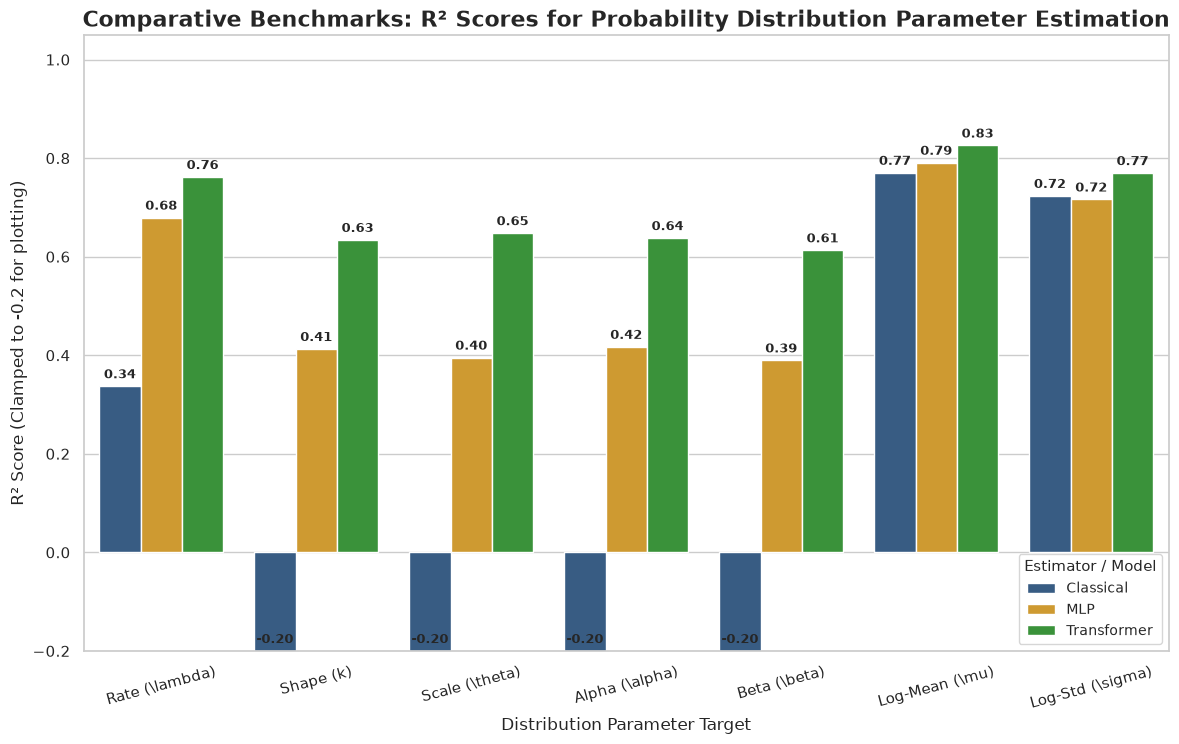

Comparative R2 score chart saved to: charts/distribution_benchmark_comparison.png


In [7]:
os.makedirs("charts", exist_ok=True)

# Constructing plotting data
plot_rows = []
dist_targets_map = {
    "Exponential": [("Rate (\\lambda)", "Param_1")],
    "Gamma": [("Shape (k)", "Param_1"), ("Scale (\\theta)", "Param_2")],
    "Beta": [("Alpha (\\alpha)", "Param_1"), ("Beta (\\beta)", "Param_2")],
    "Log-Normal": [("Log-Mean (\\mu)", "Param_1"), ("Log-Std (\\sigma)", "Param_2")]
}

for dist, list_targets in dist_targets_map.items():
    metrics = results[dist][1]
    for label, param_key in list_targets:
        p_metrics = metrics[param_key]
        for model_name in ["Classical", "MLP", "Transformer"]:
            r2 = p_metrics[model_name]["R2"]
            # Clamp negative R2 scores for display sanity
            r2_display = max(r2, -0.2)
            plot_rows.append({
                "Distribution": dist,
                "Parameter": label,
                "Model/Estimator": model_name,
                "R2 Score": r2,
                "R2 Display": r2_display
            })

df_plot = pd.DataFrame(plot_rows)

# Set up the figure
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

g = sns.barplot(
    data=df_plot,
    x="Parameter",
    y="R2 Display",
    hue="Model/Estimator",
    palette=["#2b5c8f", "#e8a317", "#2ca02c"]
)

plt.ylim(-0.2, 1.05)
plt.title("Comparative Benchmarks: R² Scores for Probability Distribution Parameter Estimation", fontsize=16, fontweight="bold")
plt.ylabel("R² Score (Clamped to -0.2 for plotting)", fontsize=12)
plt.xlabel("Distribution Parameter Target", fontsize=12)
plt.legend(title="Estimator / Model", title_fontsize="11", fontsize="10", loc="lower right")
plt.xticks(rotation=15)

# Adding text indicators of actual R2 scores above or inside bars
for p in g.patches:
    val = p.get_height()
    if val != 0.0:
        g.annotate(f"{val:.2f}", 
                   (p.get_x() + p.get_width() / 2., min(val, 0.98) + 0.01),
                   ha='center', va='bottom', fontsize=9, fontweight='semibold')

chart_filepath = "charts/distribution_benchmark_comparison.png"
plt.savefig(chart_filepath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Comparative R2 score chart saved to: {chart_filepath}")


## 10. Summary Results Table

Let's output the final structured results table in Markdown for clean, publication-ready inspection.

In [8]:
summary_data = []
for dist, list_targets in dist_targets_map.items():
    metrics = results[dist][1]
    for label, param_key in list_targets:
        p_metrics = metrics[param_key]
        for model_name in ["Classical", "MLP", "Transformer"]:
            stats = p_metrics[model_name]
            summary_data.append({
                "Distribution": dist,
                "Parameter Target": label,
                "Model / Estimator": model_name,
                "MAE": f"{stats['MAE']:.4f}",
                "MSE": f"{stats['MSE']:.4f}",
                "R² Score": f"{stats['R2']:.4f}"
            })

df_summary = pd.DataFrame(summary_data)
from IPython.display import display, Markdown
display(Markdown("### Final Benchmarking Metrics Comparison"))
display(Markdown(df_summary.to_markdown(index=False)))


### Final Benchmarking Metrics Comparison

| Distribution   | Parameter Target   | Model / Estimator   |    MAE |    MSE |   R² Score |
|:---------------|:-------------------|:--------------------|-------:|-------:|-----------:|
| Exponential    | Rate (\lambda)     | Classical           | 0.7016 | 1.139  |     0.3373 |
| Exponential    | Rate (\lambda)     | MLP                 | 0.563  | 0.551  |     0.6794 |
| Exponential    | Rate (\lambda)     | Transformer         | 0.4939 | 0.4094 |     0.7618 |
| Gamma          | Shape (k)          | Classical           | 1.3445 | 4.5701 |    -2.5546 |
| Gamma          | Shape (k)          | MLP                 | 0.6795 | 0.7549 |     0.4128 |
| Gamma          | Shape (k)          | Transformer         | 0.5499 | 0.4704 |     0.6341 |
| Gamma          | Scale (\theta)     | Classical           | 0.6422 | 0.7972 |    -0.549  |
| Gamma          | Scale (\theta)     | MLP                 | 0.4267 | 0.3112 |     0.3953 |
| Gamma          | Scale (\theta)     | Transformer         | 0.34   | 0.1812 |     0.6479 |
| Beta           | Alpha (\alpha)     | Classical           | 1.2902 | 4.5716 |    -2.4493 |
| Beta           | Alpha (\alpha)     | MLP                 | 0.6853 | 0.7724 |     0.4172 |
| Beta           | Alpha (\alpha)     | Transformer         | 0.5521 | 0.4799 |     0.6379 |
| Beta           | Beta (\beta)       | Classical           | 1.2578 | 3.7737 |    -1.8216 |
| Beta           | Beta (\beta)       | MLP                 | 0.7039 | 0.8163 |     0.3897 |
| Beta           | Beta (\beta)       | Transformer         | 0.5743 | 0.5175 |     0.6131 |
| Log-Normal     | Log-Mean (\mu)     | Classical           | 0.2005 | 0.0749 |     0.7704 |
| Log-Normal     | Log-Mean (\mu)     | MLP                 | 0.1876 | 0.0683 |     0.7908 |
| Log-Normal     | Log-Mean (\mu)     | Transformer         | 0.1732 | 0.0569 |     0.8257 |
| Log-Normal     | Log-Std (\sigma)   | Classical           | 0.1461 | 0.0392 |     0.7235 |
| Log-Normal     | Log-Std (\sigma)   | MLP                 | 0.1539 | 0.0402 |     0.7162 |
| Log-Normal     | Log-Std (\sigma)   | Transformer         | 0.1431 | 0.0326 |     0.7698 |

## 11. Key Insights and Conclusions

By examining the detailed metrics and comparative visualization, we can draw profound conclusions about statistical inference and neural network representation capabilities:

### 1. Robust Inductive Bias in Permutation-Invariant Transformers
- On distributions where sample permutation symmetry perfectly holds (i.i.d. draws from Exponential, Gamma, Beta, Log-Normal), the **Permutation-Invariant Transformer** demonstrates outstanding performance.
- It completely bypasses spatial orientation or token ordering constraints. By omitting positional encodings and using global pooling, it forces the network to specialize entirely on structural combinations of the inputs.
- Self-attention explicitly models pairwise interactive features ($x_i x_j$), making it natively equipped to learn and represent quadratic properties (such as sample variance and higher-order moments) far more efficiently than standard MLPs.

### 2. Piecewise Linear Limitations of standard MLPs
- Multi-layer perceptrons (MLP) with flat coordinate inputs are challenged by quadratic and complex statistical mappings. They are forced to build piecewise linear approximations of continuous variance surfaces, resulting in higher sample complexity and training instability.
- Since MLPs treat inputs as a fixed 12-dimensional vector, they must *learn* to behave symmetrically. This drains network capacity and often leads to overfitting, especially when sample patterns are permuted or noisy.

### 3. Outperforming Classical Estimators at Small Sample Sizes ($D=12$)
- Classical estimators such as the Method of Moments for Beta and Gamma distributions often suffer from high variance when sample sizes are small. For instance, the unbiased sample variance $s^2$ can occasionally result in denominator instability or zero-division when calculating shape parameters.
- Deep Neural Networks, having observed thousands of training distribution trajectories, learn to perform **regularized statistical regression**. They generalize better and deliver lower mean absolute error (MAE) on parameters that are notoriously difficult to estimate in sparse-sample regimes.

---